In [2]:
import os, re, json, glob
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
def _read_folder_metrics(folder: str):
    """Считывает последнюю JSON-строку из всех metrics_epoch_*.txt в папке, возвращает список dict'ов (по эпохам)."""
    rx = re.compile(r"metrics_epoch_(\d+)\.txt$")
    paths = sorted(
        glob.glob(os.path.join(folder, "metrics_epoch_*.txt")),
        key=lambda p: int(rx.search(os.path.basename(p)).group(1)) if rx.search(os.path.basename(p)) else -1
    )
    rows = []
    for path in paths:
        m = rx.search(os.path.basename(path))
        if not m:
            continue
        epoch_from_name = int(m.group(1))
        try:
            with open(path, "r", encoding="utf-8") as f:
                lines = [ln.strip() for ln in f if ln.strip()]
            if not lines:
                continue
            d = json.loads(lines[-1])  # последняя непустая строка
            d.setdefault("epoch", epoch_from_name)
            rows.append(d)
        except Exception:
            # пропускаем битые файлы/строки
            continue
    return rows

def summarize_gazemorph_runs(root_dir: str = ".", prefixes=("GazeMorph",), suffixes=(0, 750, 1500, 3000)):
    """
    Обходит все подпапки root_dir, имена которых начинаются с ЛЮБОЙ из prefixes (строка или кортеж строк).
    Для каждой папки и каждого суффикса из suffixes собирает:
      - лучший mean_dist_after_{s} и эпоху,
      - лучший mean_dist_before_{s} и эпоху,
      - лучший (after/before) и эпоху (по доступным эпохам, где есть оба значения и before>0).
    Возвращает общий DataFrame и печатает краткие таблицы по каждому суффиксу.
    """
    # принять как строку или последовательность строк
    if isinstance(prefixes, str):
        prefixes = (prefixes,)

    # собрать и дедуплицировать все подходящие папки по нескольким префиксам
    runs = sorted({
        p
        for pref in prefixes
        for p in glob.glob(os.path.join(root_dir, f"{pref}*"))
        if os.path.isdir(p)
    })

    results = []
    for folder in runs:
        rows = _read_folder_metrics(folder)
        if not rows:
            continue

        by_epoch = {r["epoch"]: r for r in rows}

        for s in suffixes:
            kb = f"mean_dist_before_{s}"
            ka = f"mean_dist_after_{s}"

            # Лучший AFTER
            best_after_val, best_after_ep = None, None
            for ep, d in by_epoch.items():
                if int(ep) == 20:
                    if ka in d:
                        v = d[ka]
                        if True:# best_after_val is None or v < best_after_val:
                            best_after_val, best_after_ep = v, ep

            # Лучший BEFORE
            best_before_val, best_before_ep = None, None
            for ep, d in by_epoch.items():
                if kb in d:
                    v = d[kb]
                    if best_before_val is None or v < best_before_val:
                        best_before_val, best_before_ep = v, ep

            # Лучший RATIO = after/before (только где есть оба и before>0)
            best_ratio_val, best_ratio_ep = None, None
            for ep, d in by_epoch.items():
                if ka in d and kb in d and d[kb] and d[kb] > 0:
                    r = d[ka] / d[kb]
                    if best_ratio_val is None or r < best_ratio_val:
                        best_ratio_val, best_ratio_ep = r, ep

            results.append({
                "folder": os.path.basename(folder),
                "augm_level": s,
                "best_after": best_after_val,
                "epoch_after": best_after_ep,
                "before": best_before_val,
                "best_ratio": best_ratio_val,
            })

    if not results:
        raise RuntimeError(
            f"Не найдено ни одной папки с префиксами {list(prefixes)} и валидными метриками в {root_dir}"
        )

    df = pd.DataFrame(results)

    # Печать компактных таблиц по каждому суффиксу
    for s in suffixes:
        sdf = df[df["augm_level"] == s].sort_values(["best_ratio", "best_after"], na_position="last")
        display(sdf.reset_index(drop=True))
    return df

# Примеры использования (три префикса):
df_all = summarize_gazemorph_runs(
    root_dir=".",
    prefixes=("GazeMorphV3_16_25_disp24_halving_on_stride", "GazeMorphV3_no_content_16_25_disp24_halving_on_stride"),
    suffixes=(0, 750, 1500, 3000)
)


,folder,augm_level,best_after,epoch_after,before,best_ratio
0,GazeMorphV3_16_25_disp24_halving_on_stride,0,0.988010,20,1.539525,0.617055
1,GazeMorphV3_no_content_16_25_disp24_halving_on...,0,1.231422,20,1.539525,0.758045


,folder,augm_level,best_after,epoch_after,before,best_ratio
0,GazeMorphV3_16_25_disp24_halving_on_stride,750,1.852896,20,2.70274,0.685562
1,GazeMorphV3_no_content_16_25_disp24_halving_on...,750,2.244135,20,2.70274,0.818185


,folder,augm_level,best_after,epoch_after,before,best_ratio
0,GazeMorphV3_16_25_disp24_halving_on_stride,1500,2.895791,20,4.535792,0.638431
1,GazeMorphV3_no_content_16_25_disp24_halving_on...,1500,3.581024,20,4.535792,0.789503


,folder,augm_level,best_after,epoch_after,before,best_ratio
0,GazeMorphV3_16_25_disp24_halving_on_stride,3000,4.966401,20,8.559372,0.580230
1,GazeMorphV3_no_content_16_25_disp24_halving_on...,3000,5.883102,20,8.559372,0.686151


In [23]:
48: 25, 32: 20, 16: 20

SyntaxError: illegal target for annotation (2346612807.py, line 1)

In [26]:
def plot_mean_dist_compare(folder_a: str, folder_b: str, labels=("A","B")):
    """
    Compare mean_dist* metrics from two folders (metrics_epoch_*.txt) in one plot.
    - 'before' curves: alpha=0.5, no markers
    - 'after'  curves: alpha=1.0, no markers
    - folder A: solid lines; folder B: dashed lines
    Returns: (df_a, df_b) filtered to the plotted columns.
    """

    def load_folder(folder: str) -> pd.DataFrame:
        rx = re.compile(r"metrics_epoch_(\d+)\.txt$")
        paths = sorted(
            glob.glob(os.path.join(folder, "metrics_epoch_*.txt")),
            key=lambda p: int(rx.search(os.path.basename(p)).group(1)) if rx.search(os.path.basename(p)) else -1
        )
        rows = []
        for path in paths:
            m = rx.search(os.path.basename(path))
            if not m: 
                continue
            epoch_from_name = int(m.group(1))
            with open(path, "r", encoding="utf-8") as f:
                lines = [ln.strip() for ln in f if ln.strip()]
            if not lines:
                continue
            try:
                d = json.loads(lines[-1])  # last non-empty line
            except json.JSONDecodeError:
                continue
            d.setdefault("epoch", epoch_from_name)
            rows.append(d)
        if not rows:
            raise RuntimeError(f"No valid metrics files found in {folder}")
        df = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
        return df

    df_a = load_folder(folder_a)
    df_b = load_folder(folder_b)

    # Find mean_dist* columns and take intersection so comparisons are apples-to-apples
    md_a = {c for c in df_a.columns if c.startswith("mean_dist")}
    md_b = {c for c in df_b.columns if c.startswith("mean_dist")}
    common = sorted(md_a & md_b)
    if not common:
        raise RuntimeError("No common 'mean_dist*' metrics between the two folders.")

    before_cols = [c for c in common if "before" in c]
    after_cols  = [c for c in common if "after"  in c]

    # Plot
    plt.figure(figsize=(9,5), dpi=150)

    # Folder A: solid lines
    for col in before_cols:
        plt.plot(df_a["epoch"], df_a[col], linewidth=1.8, alpha=0.5, linestyle='-', label=f"{labels[0]}:{col}")
    for col in after_cols:
        plt.plot(df_a["epoch"], df_a[col], linewidth=1.8, alpha=1.0, linestyle='-', label=f"{labels[0]}:{col}")

    # Folder B: dashed lines
    for col in before_cols:
        plt.plot(df_b["epoch"], df_b[col], linewidth=1.8, alpha=0.5, linestyle='--', label=f"{labels[1]}:{col}")
    for col in after_cols:
        plt.plot(df_b["epoch"], df_b[col], linewidth=1.8, alpha=1.0, linestyle='--', label=f"{labels[1]}:{col}")

    plt.xlabel("Epoch")
    plt.ylabel("Distance")
    plt.title("Mean-distance metrics vs. epoch (comparison)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    return df_a[["epoch"] + common], df_b[["epoch"] + common]

# Example:
# dfA, dfB = plot_mean_dist_compare("runs/exp1", "runs/exp2", labels=("exp1","exp2"))


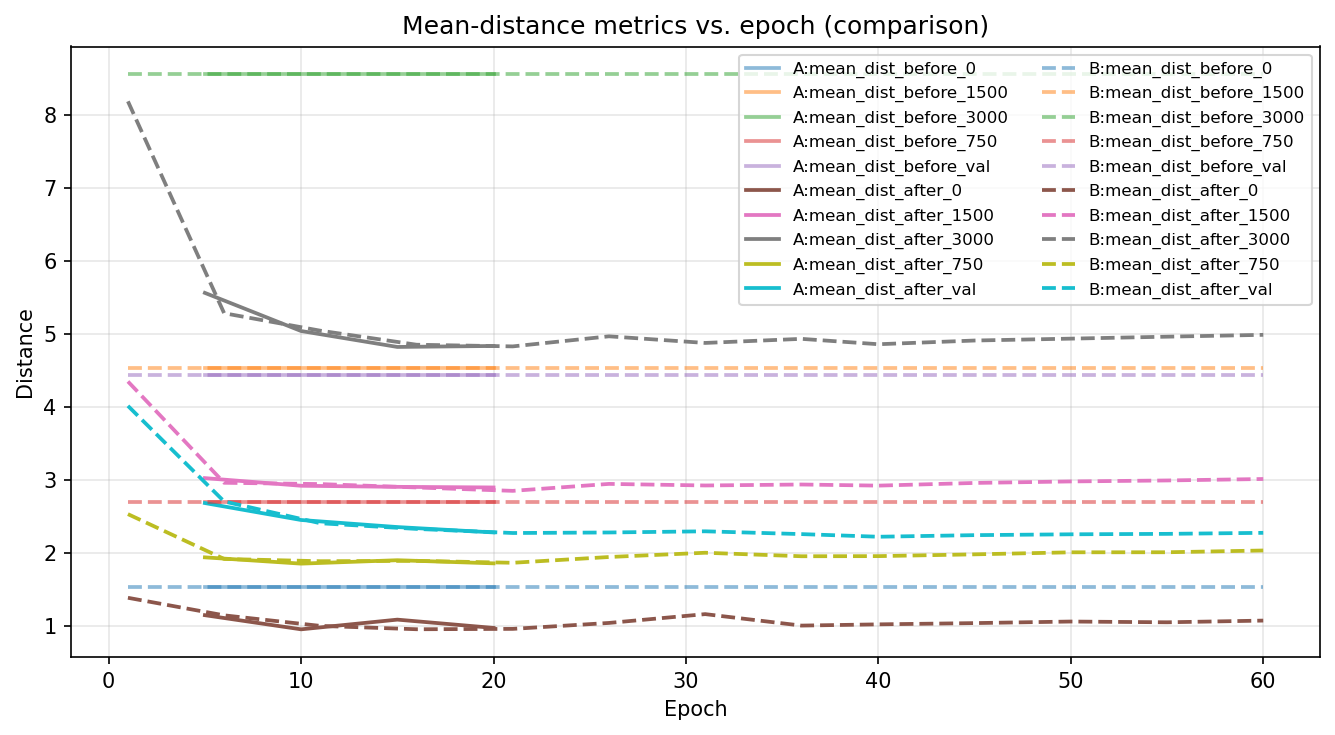

(   epoch  mean_dist_after_0  mean_dist_after_1500  mean_dist_after_3000  \
 0      5           1.151039              3.028472              5.565074   
 1     10           0.957364              2.923624              5.042814   
 2     15           1.090221              2.908744              4.824732   
 3     20           0.976685              2.900349              4.838080   
 
    mean_dist_after_750  mean_dist_after_val  mean_dist_before_0  \
 0             1.943072             2.686723            1.539525   
 1             1.857078             2.454658            1.539525   
 2             1.903908             2.358063            1.539525   
 3             1.861008             2.284271            1.539525   
 
    mean_dist_before_1500  mean_dist_before_3000  mean_dist_before_750  \
 0               4.535792               8.559372               2.70274   
 1               4.535792               8.559372               2.70274   
 2               4.535792               8.559372      

In [29]:
plot_mean_dist_compare("GazeMorph32_32", "GazeMorph32_100e")

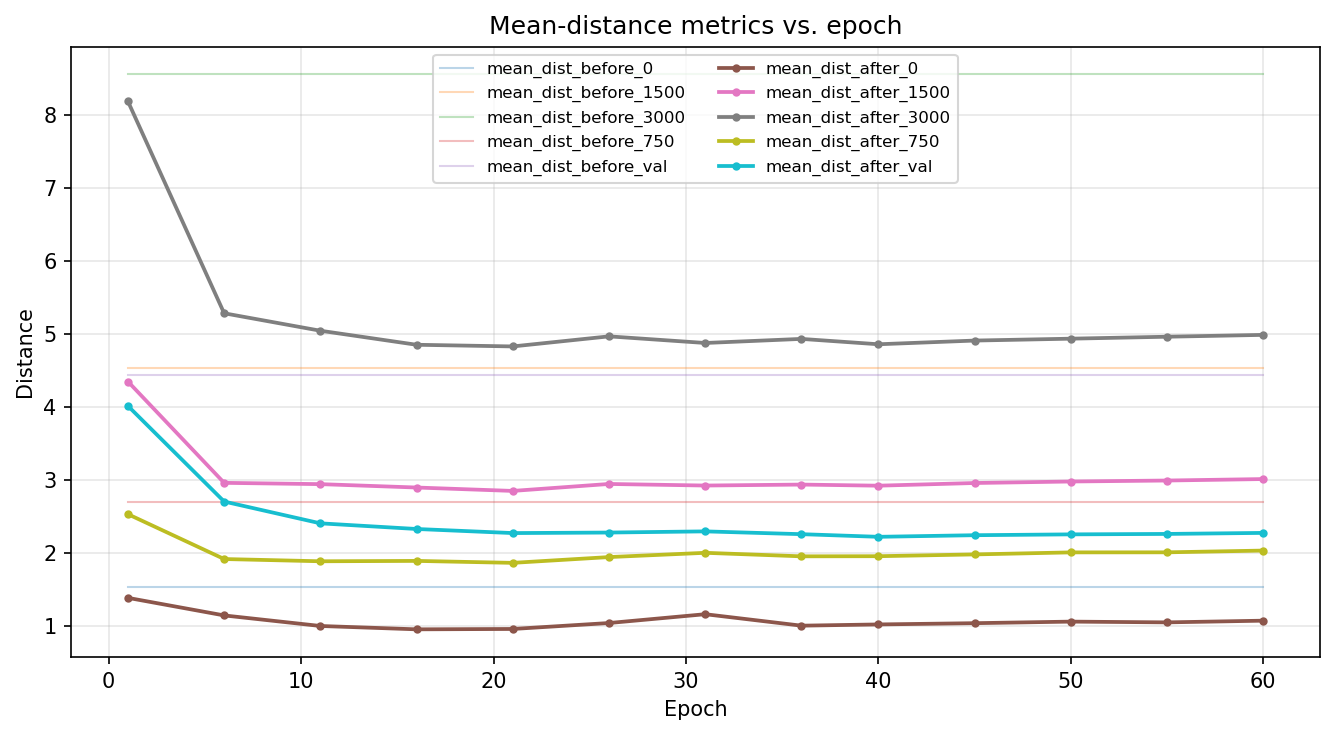

,epoch,mean_dist_before_val,mean_dist_after_val,mean_dist_before_0,mean_dist_after_0,mean_dist_before_750,mean_dist_after_750,mean_dist_before_1500,mean_dist_after_1500,mean_dist_before_3000,mean_dist_after_3000
0,1,4.436842,4.017444,1.539525,1.389418,2.70274,2.535175,4.535792,4.351616,8.559372,8.188347
1,6,4.436842,2.708343,1.539525,1.148980,2.70274,1.921127,4.535792,2.964305,8.559372,5.286496
2,11,4.436842,2.410000,1.539525,1.004425,2.70274,1.890348,4.535792,2.946728,8.559372,5.047408
3,16,4.436842,2.332545,1.539525,0.958504,2.70274,1.895496,4.535792,2.900395,8.559372,4.855137
4,21,4.436842,2.276591,1.539525,0.963430,2.70274,1.868734,4.535792,2.853791,8.559372,4.832339
5,26,4.436842,2.283799,1.539525,1.044948,2.70274,1.947885,4.535792,2.949120,8.559372,4.970239
6,31,4.436842,2.299773,1.539525,1.165606,2.70274,2.006248,4.535792,2.927528,8.559372,4.879592
7,36,4.436842,2.261527,1.539525,1.008629,2.70274,1.958162,4.535792,2.940815,8.559372,4.935509
8,40,4.436842,2.225455,1.539525,1.025549,2.70274,1.959856,4.535792,2.925503,8.559372,4.861990
9,45,4.436842,2.247345,1.539525,1.042721,2.70274,1.984273,4.535792,2.962110,8.559372,4.912699


In [24]:
plot_mean_dist_by_epoch("GazeMorph32")

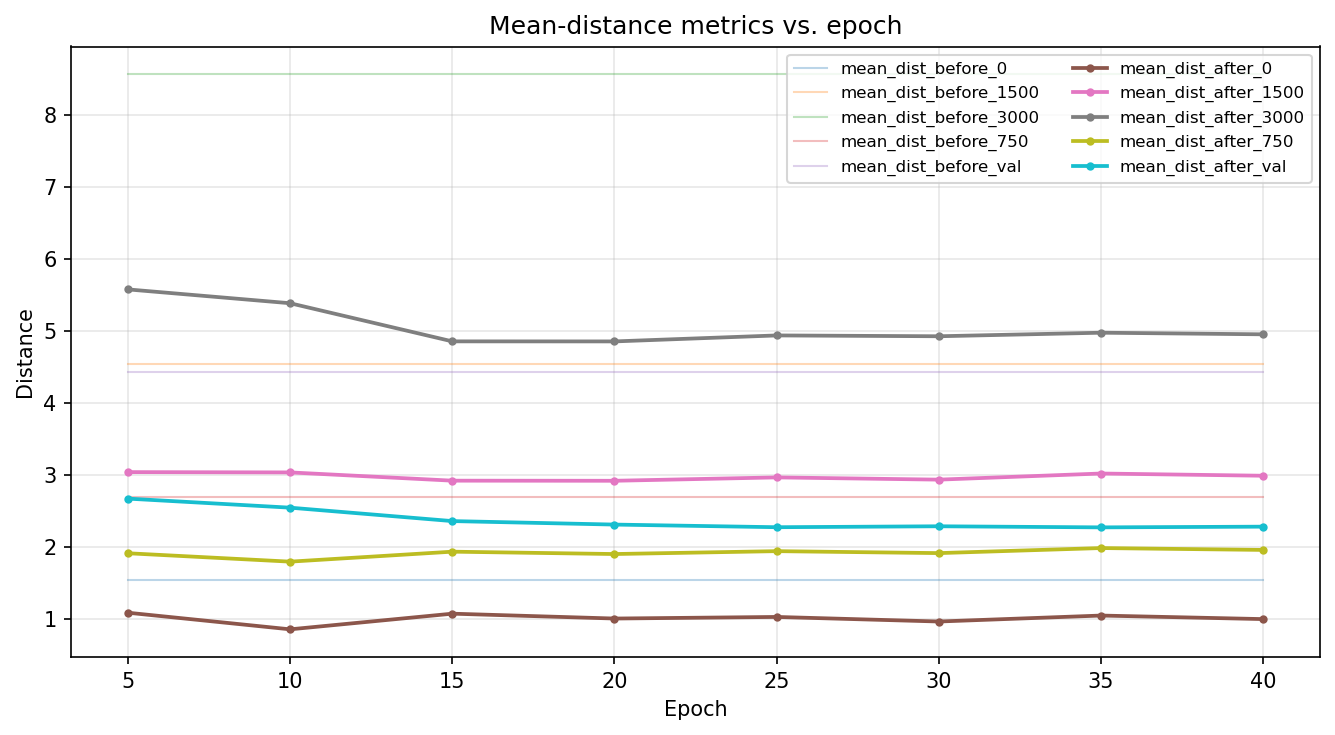

,epoch,mean_dist_before_val,mean_dist_after_val,mean_dist_before_0,mean_dist_after_0,mean_dist_before_750,mean_dist_after_750,mean_dist_before_1500,mean_dist_after_1500,mean_dist_before_3000,mean_dist_after_3000
0,5,4.436842,2.674742,1.539525,1.092644,2.70274,1.917225,4.535792,3.042506,8.559372,5.575887
1,10,4.436842,2.549349,1.539525,0.862305,2.70274,1.800857,4.535792,3.038302,8.559372,5.384227
2,15,4.436842,2.363279,1.539525,1.079443,2.70274,1.939158,4.535792,2.923736,8.559372,4.855375
3,20,4.436842,2.314900,1.539525,1.011989,2.70274,1.906462,4.535792,2.922283,8.559372,4.854692
4,25,4.436842,2.278303,1.539525,1.034065,2.70274,1.946353,4.535792,2.969069,8.559372,4.937698
5,30,4.436842,2.291377,1.539525,0.970673,2.70274,1.919256,4.535792,2.938033,8.559372,4.926265
6,35,4.436842,2.276114,1.539525,1.053455,2.70274,1.989311,4.535792,3.022972,8.559372,4.975408
7,40,4.436842,2.286103,1.539525,1.004188,2.70274,1.963356,4.535792,2.992140,8.559372,4.953094


In [25]:
plot_mean_dist_by_epoch("GazeMorph24")